<a href="https://colab.research.google.com/github/fredericmenezes/ecs-brkga-research/blob/main/BRKGA_BIASED_x_BLX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Executando comparação...


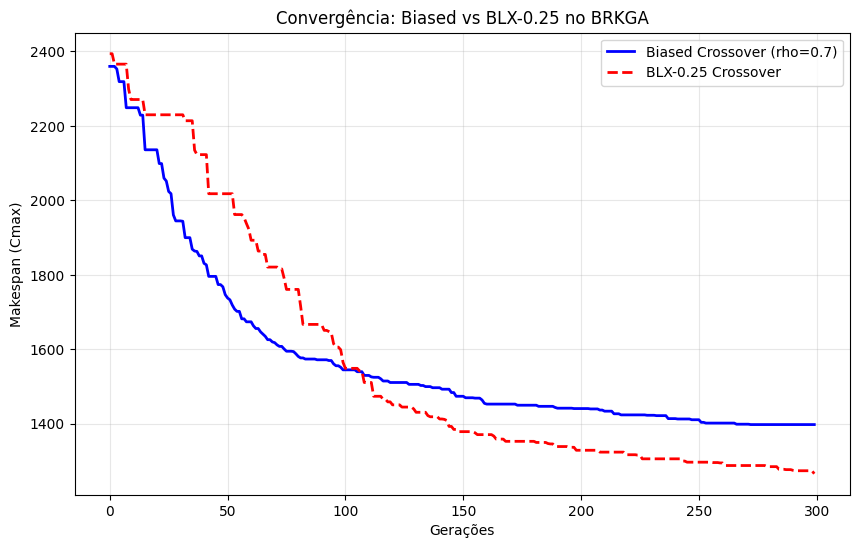

Resultado Final Biased: 1398
Resultado Final BLX: 1266


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import copy

# --- PARÂMETROS DO TESTE ---
N_MACHINES = 10
N_JOBS = 50
POP_SIZE = 200
GENS = 300
ALPHA = 0.10 # Parâmetro do BLX
RHO_E = 0.7  # Parâmetro do Biased
PERC_ELITE = 0.2
PERC_MUTAT = 0.1

class Experiment_Engine:
    def __init__(self, n_machines):
        self.n_machines = n_machines

    def bucket_decode(self, keys, n_buckets=40):
        buckets = [[] for _ in range(n_buckets)]
        for i, k in enumerate(keys):
            idx = int(k * (n_buckets - 1))
            buckets[idx].append(i)
        return [item for b in buckets for item in b]

    def fitness(self, individual, proc_times, m_ready):
        # individual: (n_machines, n_jobs)
        schedules = [self.bucket_decode(individual[m]) for m in range(self.n_machines)]
        m_free = list(m_ready)
        ft = {jid: [0]*self.n_machines for jid in range(N_JOBS)}

        for m in range(self.n_machines):
            for j_id in schedules[m]:
                dur = proc_times[j_id][m]
                ready = ft[j_id][m-1] if m > 0 else 0
                st = max(m_free[m], ready)
                ft[j_id][m] = st + dur
                m_free[m] = st + dur
        return max(m_free)

def crossover_biased(p_elite, p_non_elite, rho_e):
    """Herança discreta gene a gene (Padrão BRKGA)."""
    mask = np.random.rand(*p_elite.shape) < rho_e
    return np.where(mask, p_elite, p_non_elite)

def crossover_blx(p1, p2, alpha):
    """Cruzamento aritmético que expande o hiperplano."""
    # p1 e p2 são matrizes (n_machines, n_jobs)
    c_min = np.minimum(p1, p2)
    c_max = np.maximum(p1, p2)
    diff = c_max - c_min

    low = c_min - alpha * diff
    high = c_max + alpha * diff

    # Gera valor aleatório no intervalo expandido
    child = np.random.uniform(low, high)

    # Clipping para manter no espaço [0, 1] do BRKGA
    return np.clip(child, 0, 1)

def run_brkga(mode, proc_times, m_ready, engine):
    pop = np.random.rand(POP_SIZE, N_MACHINES, N_JOBS)
    history = []

    n_e = int(POP_SIZE * PERC_ELITE)
    n_m = int(POP_SIZE * PERC_MUTAT)
    n_c = POP_SIZE - n_e - n_m

    for _ in range(GENS):
        fits = [(engine.fitness(ind, proc_times, m_ready), i) for i, ind in enumerate(pop)]
        fits.sort(key=lambda x: x[0])
        history.append(fits[0][0])

        new_pop = np.zeros_like(pop)
        elite_indices = [f[1] for f in fits[:n_e]]
        new_pop[:n_e] = pop[elite_indices] # Elitismo
        new_pop[n_e:n_e+n_m] = np.random.rand(n_m, N_MACHINES, N_JOBS) # Mutantes

        for i in range(n_e+n_m, POP_SIZE):
            p1 = pop[random.choice(elite_indices)]
            p2 = pop[fits[random.randint(n_e, POP_SIZE-1)][1]]

            if mode == "BIASED":
                new_pop[i] = crossover_biased(p1, p2, RHO_E)
            else: # BLX-Alpha
                new_pop[i] = crossover_blx(p1, p2, ALPHA)
        pop = new_pop
    return history

# --- EXECUÇÃO DO EXPERIMENTO ---
engine = Experiment_Engine(N_MACHINES)
proc_times = {i: np.random.randint(5, 20, N_MACHINES) for i in range(N_JOBS)}
m_ready = [0] * N_MACHINES  # Corrected line: Initialize m_ready with N_MACHINES zeros

print("Executando comparação...")
biased_history = run_brkga("BIASED", proc_times, m_ready, engine)
blx_history = run_brkga("BLX", proc_times, m_ready, engine)

# Plotagem
plt.figure(figsize=(10, 6))
plt.plot(biased_history, label=f"Biased Crossover (rho={RHO_E})", color='blue', linewidth=2)
plt.plot(blx_history, label=f"BLX-0.25 Crossover", color='red', linestyle='--', linewidth=2)
plt.title("Convergência: Biased vs BLX-0.25 no BRKGA")
plt.xlabel("Gerações")
plt.ylabel("Makespan (Cmax)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Resultado Final Biased: {biased_history[-1]}")
print(f"Resultado Final BLX: {blx_history[-1]}")

<>:112: SyntaxWarning: invalid escape sequence '\s'
<>:112: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_207/3999429779.py:112: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Convergência Média ($N={N_RUNS}$) com $\sigma$ Shaded Area")


Modo BLX | Run 4/4 completa.


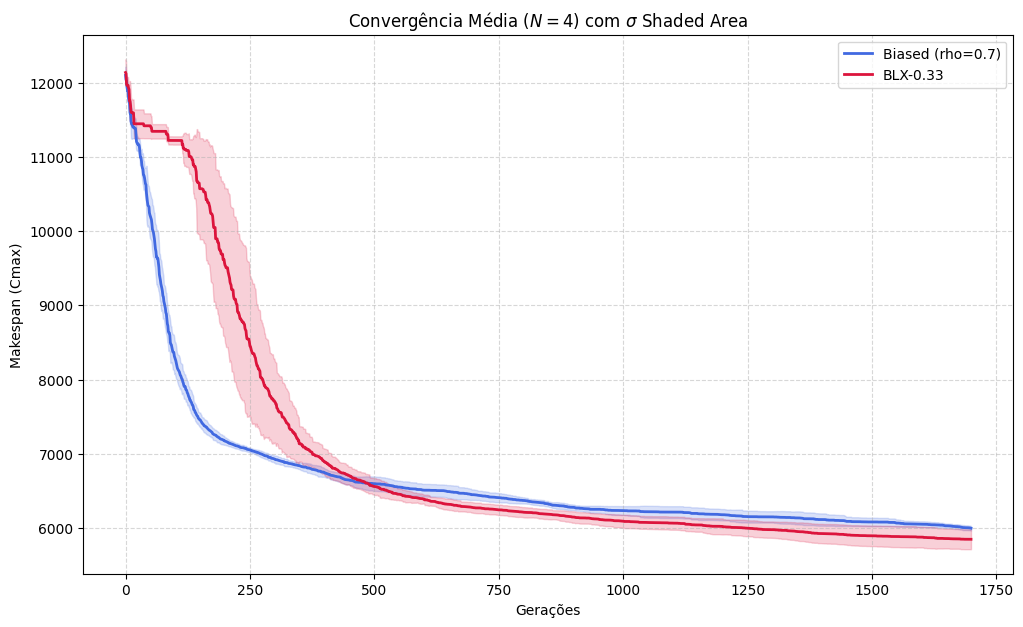


Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 5964.00      | 5713.00     
Média Final          | 5995.00      | 5845.75     
Desvio Padrão        | 30.96        | 134.17      


In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import copy
from scipy import stats
### DISCONTINUADO POR QUE NÃO ENTENDO ESSE RECURSO DE LOG DE ALTERAÇÕES

# --- CONFIGURAÇÕES DO EXPERIMENTO ---
N_RUNS = 4
N_JOBS = 100        # Instância maior conforme solicitado
N_MACHINES = 5
POP_SIZE = 500
GENS = 1700          # Execução prolongada
ALPHA = 0.33
RHO_E = 0.7
PERC_ELITE = 0.2
PERC_MUTAT = 0.1

class StatsEngine:
    def __init__(self, n_machines):
        self.n_machines = n_machines

    def bucket_decode(self, keys, n_buckets=50):
        buckets = [[] for _ in range(n_buckets)]
        for i, k in enumerate(keys):
            idx = int(k * (n_buckets - 1))
            buckets[idx].append(i)
        return [item for b in buckets for item in b]

    def fitness(self, individual, proc_times, m_ready):
        schedules = [self.bucket_decode(individual[m]) for m in range(self.n_machines)]
        m_free = list(m_ready)
        ft = {jid: [0]*self.n_machines for jid in range(N_JOBS)}
        for m in range(self.n_machines):
            for j_id in schedules[m]:
                dur = proc_times[j_id][m]
                ready = ft[j_id][m-1] if m > 0 else 0
                st = max(m_free[m], ready)
                ft[j_id][m] = st + dur
                m_free[m] = st + dur
        return max(m_free)

def run_brkga_experiment(mode, proc_times, engine):
    all_histories = []
    final_best_solutions = []

    for run in range(N_RUNS):
        pop = np.random.rand(POP_SIZE, N_MACHINES, N_JOBS)

        history = []
        n_e, n_m = int(POP_SIZE * PERC_ELITE), int(POP_SIZE * PERC_MUTAT)

        best_run_fit = float('inf')

        for g in range(GENS):
            fits = [(engine.fitness(ind, proc_times, [0]*N_MACHINES), i) for i, ind in enumerate(pop)]
            fits.sort(key=lambda x: x[0])
            current_best = fits[0][0]
            history.append(current_best)

            if current_best < best_run_fit: best_run_fit = current_best

            new_pop = np.zeros_like(pop)
            elite_indices = [f[1] for f in fits[:n_e]]
            new_pop[:n_e] = pop[elite_indices]
            new_pop[n_e:n_e+n_m] = np.random.rand(n_m, N_MACHINES, N_JOBS)

            for i in range(n_e+n_m, POP_SIZE):
                p1 = pop[random.choice(elite_indices)]
                p2 = pop[fits[random.randint(n_e, POP_SIZE-1)][1]]

                if mode == "BIASED":
                    mask = np.random.rand(N_MACHINES, N_JOBS) < RHO_E
                    new_pop[i] = np.where(mask, p1, p2)
                else: # BLX-Alpha
                    c_min, c_max = np.minimum(p1, p2), np.maximum(p1, p2)
                    diff = c_max - c_min
                    new_pop[i] = np.clip(np.random.uniform(c_min - ALPHA*diff, c_max + ALPHA*diff), 0, 1)
            pop = new_pop

        all_histories.append(history)
        final_best_solutions.append(best_run_fit)
        print(f"Modo {mode} | Run {run+1}/{N_RUNS} completa.", end='\r')

    return np.array(all_histories), np.array(final_best_solutions)

# --- EXECUÇÃO ---
engine = StatsEngine(N_MACHINES)
proc_times = {i: np.random.randint(10, 50, N_MACHINES) for i in range(N_JOBS)}

h_biased, f_biased = run_brkga_experiment("BIASED", proc_times, engine)
h_blx, f_blx = run_brkga_experiment("BLX", proc_times, engine)
print("\n" + "="*50)
# --- CÁLCULOS ESTATÍSTICOS ---
mean_biased = np.mean(h_biased, axis=0)
std_biased = np.std(h_biased, axis=0)

mean_blx = np.mean(h_blx, axis=0)
std_blx = np.std(h_blx, axis=0)

# --- PLOTAGEM COM FAIXA DE DESVIO ---
plt.figure(figsize=(12, 7))
gens_range = range(GENS)

# Linha Biased
plt.plot(gens_range, mean_biased, label=f"Biased (rho={RHO_E})", color='royalblue', linewidth=2)
plt.fill_between(gens_range, mean_biased - std_biased, mean_biased + std_biased, color='royalblue', alpha=0.2)

# Linha BLX
plt.plot(gens_range, mean_blx, label=f"BLX-0.33", color='crimson', linestyle='-', linewidth=2)
plt.fill_between(gens_range, mean_blx - std_blx, mean_blx + std_blx, color='crimson', alpha=0.2)

plt.title(f"Convergência Média ($N={N_RUNS}$) com r'$\sigma$' Shaded Area")
plt.xlabel("Gerações")
plt.ylabel("Makespan (Cmax)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# --- TABELA FINAL ---
print("\n" + "="*50)
print(f"{'Métrica':<20} | {'Biased':<12} | {'BLX-0.33':<12}")
print("-" * 50)
print(f"{'Melhor Solução':<20} | {np.min(f_biased):<12.2f} | {np.min(f_blx):<12.2f}")
print(f"{'Média Final':<20} | {np.mean(f_biased):<12.2f} | {np.mean(f_blx):<12.2f}")
print(f"{'Desvio Padrão':<20} | {np.std(f_biased):<12.2f} | {np.std(f_blx):<12.2f}")
print("="*50)

==================================================

Métrica              | Biased       | BLX-0.33    
--------------------------------------------------

Melhor Solução       | 5964.00      | 5713.00     

Média Final          | 5995.00      | 5845.75     

Desvio Padrão        | 30.96        | 134.17      
==================================================



# --- CONFIGURAÇÕES DO EXPERIMENTO ---
N_RUNS = 4
N_JOBS = 100        # Instância maior conforme solicitado
N_MACHINES = 5
POP_SIZE = 500
GENS = 1700          # Execução prolongada
ALPHA = 0.33  ###nao mexer
RHO_E = 0.7
PERC_ELITE = 0.2
PERC_MUTAT = 0.1

Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 32251.00     | 36536.00    
Média Final          | 32423.00     | 36668.00    
Desvio Padrão        | 172.00       | 132.00     

# --- CONFIGURAÇÕES DO EXPERIMENTO ---
N_RUNS = 2
N_JOBS = 200        # Instância maior conforme solicitado
N_MACHINES = 10
POP_SIZE = 600
GENS = 1200          # Execução prolongada
ALPHA = 0.33
RHO_E = 0.7
PERC_ELITE = 0.2
PERC_MUTAT = 0.1

-------------------

==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 28893.00     | 31152.00    
Média Final          | 29085.50     | 31270.00    
Desvio Padrão        | 192.50       | 118.00      
==================================================

<>:111: SyntaxWarning: invalid escape sequence '\s'
<>:111: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4287/196817697.py:111: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Convergência Média ($N={N_RUNS}$) com $\sigma$ Shaded Area")


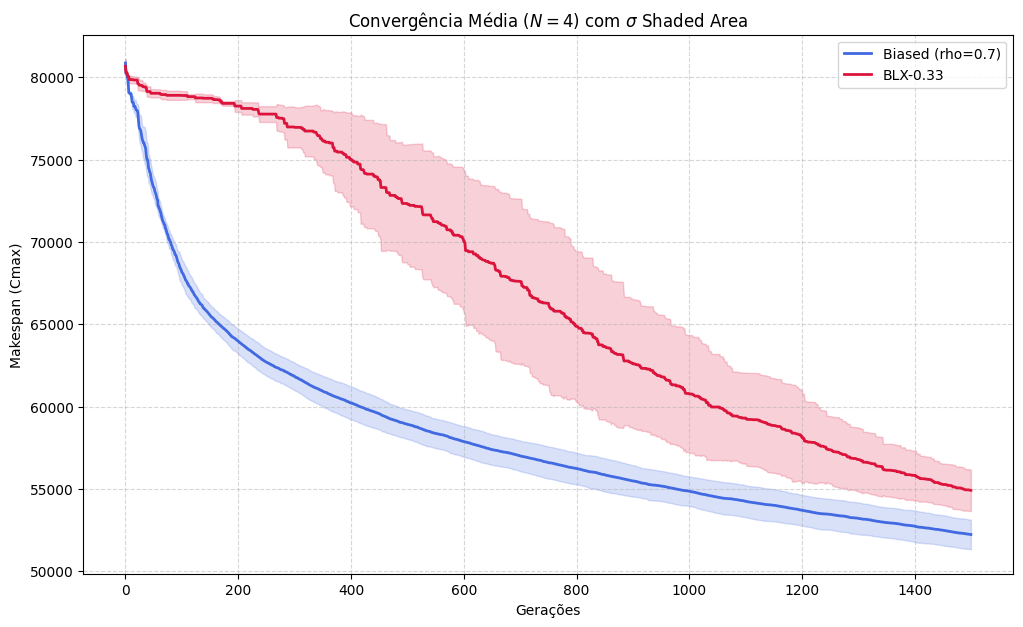


Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 51077.00     | 53235.00    
Média Final          | 52232.75     | 54914.50    
Desvio Padrão        | 893.61       | 1252.96     


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import copy
from scipy import stats

# --- CONFIGURAÇÕES DO EXPERIMENTO ---
N_RUNS = 4
N_JOBS = 300        # Instância maior conforme solicitado
N_MACHINES = 10
POP_SIZE = 200
GENS = 1500          # Execução prolongada
ALPHA = 0.4
RHO_E = 0.7
PERC_ELITE = 0.2
PERC_MUTAT = 0.1

class StatsEngine:
    def __init__(self, n_machines):
        self.n_machines = n_machines

    def bucket_decode(self, keys, n_buckets=50):
        buckets = [[] for _ in range(n_buckets)]
        for i, k in enumerate(keys):
            idx = int(k * (n_buckets - 1))
            buckets[idx].append(i)
        return [item for b in buckets for item in b]

    def fitness(self, individual, proc_times, m_ready):
        schedules = [self.bucket_decode(individual[m]) for m in range(self.n_machines)]
        m_free = list(m_ready)
        ft = {jid: [0]*self.n_machines for jid in range(N_JOBS)}
        for m in range(self.n_machines):
            for j_id in schedules[m]:
                dur = proc_times[j_id][m]
                ready = ft[j_id][m-1] if m > 0 else 0
                st = max(m_free[m], ready)
                ft[j_id][m] = st + dur
                m_free[m] = st + dur
        return max(m_free)

def run_brkga_experiment(mode, proc_times, engine):
    all_histories = []
    final_best_solutions = []

    for run in range(N_RUNS):
        pop = np.random.rand(POP_SIZE, N_MACHINES, N_JOBS)
        history = []
        n_e, n_m = int(POP_SIZE * PERC_ELITE), int(POP_SIZE * PERC_MUTAT)

        best_run_fit = float('inf')

        for g in range(GENS):
            fits = [(engine.fitness(ind, proc_times, [0]*N_MACHINES), i) for i, ind in enumerate(pop)]
            fits.sort(key=lambda x: x[0])
            current_best = fits[0][0]
            history.append(current_best)

            if current_best < best_run_fit: best_run_fit = current_best

            new_pop = np.zeros_like(pop)
            elite_indices = [f[1] for f in fits[:n_e]]
            new_pop[:n_e] = pop[elite_indices]
            new_pop[n_e:n_e+n_m] = np.random.rand(n_m, N_MACHINES, N_JOBS)

            for i in range(n_e+n_m, POP_SIZE):
                p1 = pop[random.choice(elite_indices)]
                p2 = pop[fits[random.randint(n_e, POP_SIZE-1)][1]]

                if mode == "BIASED":
                    mask = np.random.rand(N_MACHINES, N_JOBS) < RHO_E
                    new_pop[i] = np.where(mask, p1, p2)
                else: # BLX-Alpha
                    c_min, c_max = np.minimum(p1, p2), np.maximum(p1, p2)
                    diff = c_max - c_min
                    new_pop[i] = np.clip(np.random.uniform(c_min - ALPHA*diff, c_max + ALPHA*diff), 0, 1)
            pop = new_pop

        all_histories.append(history)
        final_best_solutions.append(best_run_fit)
        print(f"Modo {mode} | Run {run+1}/{N_RUNS} completa.", end='\r')

    return np.array(all_histories), np.array(final_best_solutions)

# --- EXECUÇÃO ---
engine = StatsEngine(N_MACHINES)
proc_times = {i: np.random.randint(10, 50, N_MACHINES) for i in range(N_JOBS)}

h_biased, f_biased = run_brkga_experiment("BIASED", proc_times, engine)
h_blx, f_blx = run_brkga_experiment("BLX", proc_times, engine)

# --- CÁLCULOS ESTATÍSTICOS ---
mean_biased = np.mean(h_biased, axis=0)
std_biased = np.std(h_biased, axis=0)

mean_blx = np.mean(h_blx, axis=0)
std_blx = np.std(h_blx, axis=0)

# --- PLOTAGEM COM FAIXA DE DESVIO ---
plt.figure(figsize=(12, 7))
gens_range = range(GENS)

# Linha Biased
plt.plot(gens_range, mean_biased, label=f"Biased (rho={RHO_E})", color='royalblue', linewidth=2)
plt.fill_between(gens_range, mean_biased - std_biased, mean_biased + std_biased, color='royalblue', alpha=0.2)

# Linha BLX
plt.plot(gens_range, mean_blx, label=f"BLX-0.33", color='crimson', linestyle='-', linewidth=2)
plt.fill_between(gens_range, mean_blx - std_blx, mean_blx + std_blx, color='crimson', alpha=0.2)

plt.title(f"Convergência Média ($N={N_RUNS}$) com $\sigma$ Shaded Area")
plt.xlabel("Gerações")
plt.ylabel("Makespan (Cmax)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# --- TABELA FINAL ---
print("\n" + "="*50)
print(f"{'Métrica':<20} | {'Biased':<12} | {'BLX-0.33':<12}")
print("-" * 50)
print(f"{'Melhor Solução':<20} | {np.min(f_biased):<12.2f} | {np.min(f_blx):<12.2f}")
print(f"{'Média Final':<20} | {np.mean(f_biased):<12.2f} | {np.mean(f_blx):<12.2f}")
print(f"{'Desvio Padrão':<20} | {np.std(f_biased):<12.2f} | {np.std(f_blx):<12.2f}")
print("="*50)

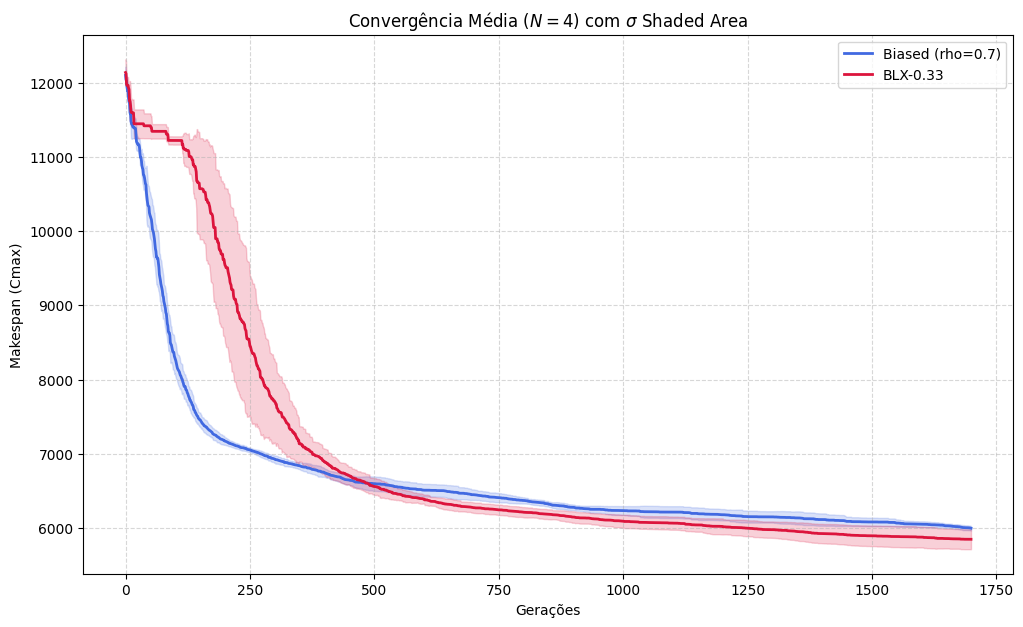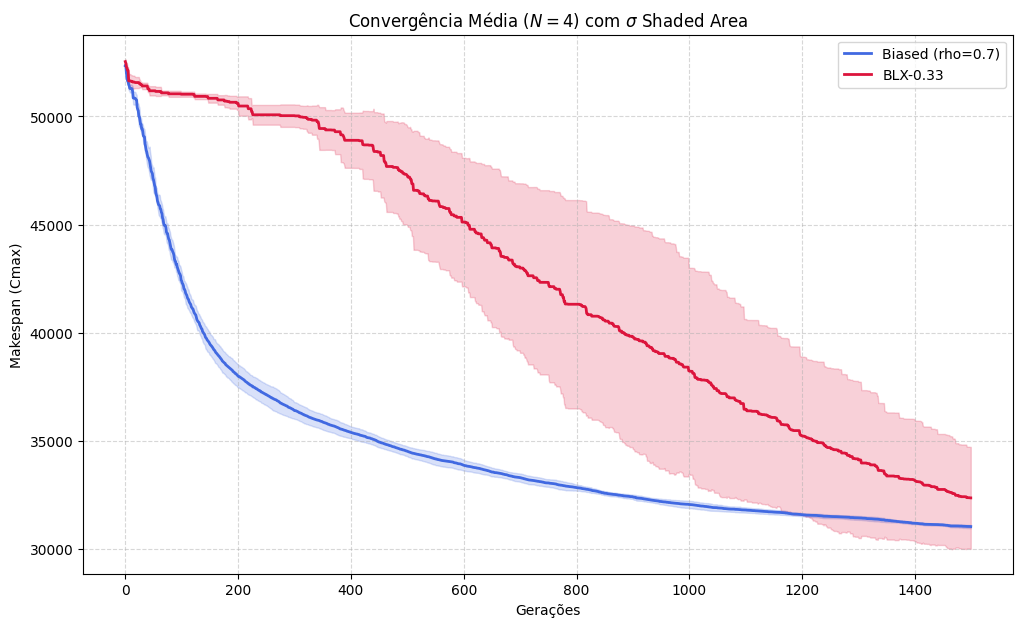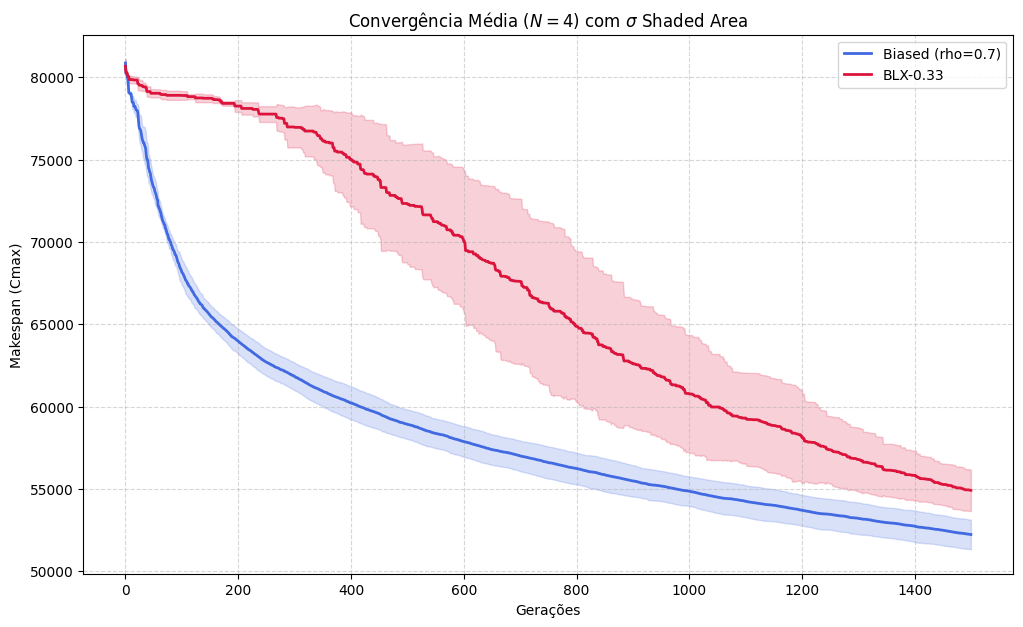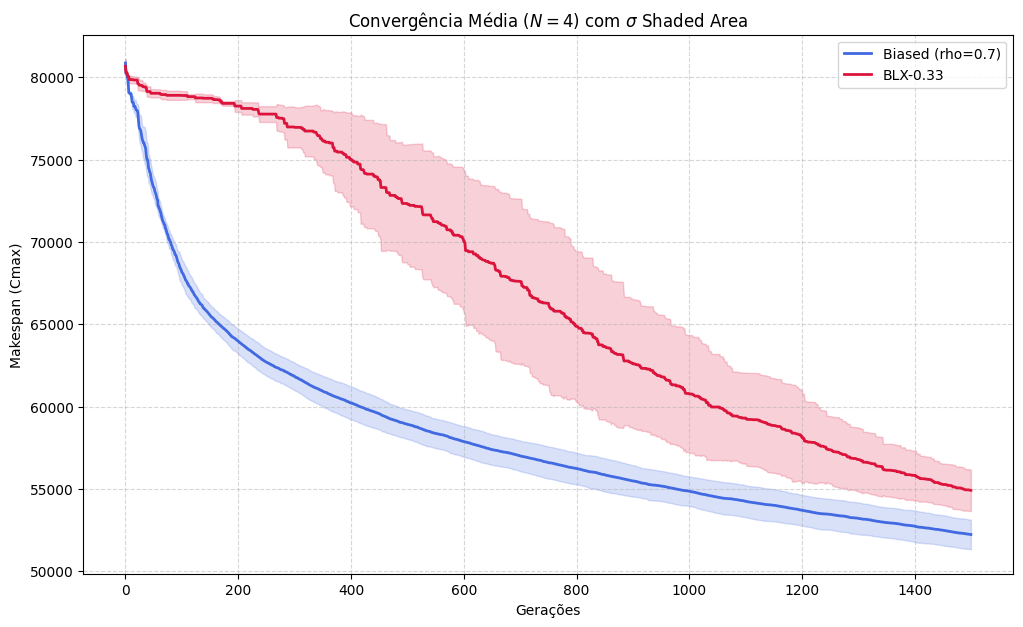

Conclusão: o Biased escala melhor, com menor variabilidade a cada iteração. Nas primeiras iterações aprimora consistentemente a população e convergindo rapidamente. Processo adicional de sintonia pode trazer um desempenho ainda melhor por meio da mutação e elitização menos agressiva.

Para uma instância de 300x10
==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 51077.00     | 53235.00    
Média Final          | 52232.75     | 54914.50    
Desvio Padrão        | 893.61       | 1252.96     
==================================================

==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 29801.00     | 30843.00    
Média Final          | 30430.50     | 32066.75    
Desvio Padrão        | 399.50       | 758.61      
==================================================

==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 31740.00     | 30831.00    
Média Final          | 32044.50     | 31247.75    
Desvio Padrão        | 277.57       | 456.42      
==================================================

==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 12041.00     | 9824.00     
Média Final          | 12160.25     | 10320.00    
Desvio Padrão        | 145.41       | 313.85      
==================================================

==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 11721.00     | 10409.00    
Média Final          | 11972.00     | 10420.50    
Desvio Padrão        | 251.00       | 11.50       
==================================================

==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 12560.00     | 13238.00    
Média Final          | 13012.00     | 13578.00    
Desvio Padrão        | 454.11       | 349.26      
==================================================

# --- CONFIGURAÇÕES DO EXPERIMENTO ---
N_RUNS = 5
N_JOBS = 100        # Instância maior conforme solicitado
N_MACHINES = 10
POP_SIZE = 500
GENS = 1000          # Execução prolongada
ALPHA = 0.33
RHO_E = 0.7
PERC_ELITE = 0.2
PERC_MUTAT = 0.1



==================================================
Métrica              | Biased       | BLX-0.33    
--------------------------------------------------
Melhor Solução       | 12407.00     | 12342.00    
Média Final          | 12723.80     | 12911.00    
Desvio Padrão        | 207.85       | 486.88      
==================================================


ÚLTIMO REGISTRO EM QUE O BLX VENCE!